In [2]:
%pip install pandas pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import requests
import os
from datetime import datetime

# URL del dataset de causas respiratorias
url = "https://datos.gob.cl/dataset/606ef5bb-11d1-475b-b69f-b980da5757f4/resource/ae6c9887-106d-4e98-8875-40bf2b836041/download/at_urg_respiratorio_semanal.parquet"

# Generar el nombre del archivo con la fecha de hoy
fecha_actual = datetime.now().strftime("%Y-%m-%d-%H%M%S")
nombre_archivo = f"../dataset/at_urg_respiratorio_{fecha_actual}.parquet"

# Descargar solo si no existe el archivo de hoy
if not os.path.exists(nombre_archivo):
    print(f"Iniciando descarga de la versión: {nombre_archivo}...")
    try:
        respuesta = requests.get(url, stream=True)
        respuesta.raise_for_status()
        with open(nombre_archivo, 'wb') as f:
            for chunk in respuesta.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Descarga completada con éxito.")
    except Exception as e:
        print(f"Error durante la descarga: {e}")
else:
    print(f"La versión del día ({fecha_actual}) ya se encuentra en la carpeta local.")

Iniciando descarga de la versión: ../dataset/at_urg_respiratorio_2026-06-17-134140.parquet...
Descarga completada con éxito.


In [4]:
%pip install pandas pyarrow fastparquet duckdb seaborn matplotlib ydata_profiling

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import glob
from datetime import datetime

fecha_actual = datetime.now().strftime("%Y-%m-%d-%H%M%S")

# 1. Definir el patrón de búsqueda de los archivos
patron = '../dataset/at_urg_respiratorio_*.parquet'

# 2. Buscar todos los archivos que coincidan con el patrón
archivos_encontrados = glob.glob(patron)

# 3. Verificar si hay archivos y seleccionar el más reciente
if archivos_encontrados:
    # Como el formato es YYYY-MM-DD, max() devolverá el archivo con la fecha más reciente
    archivo_mas_reciente = max(archivos_encontrados)
    
    print(f"Cargando el archivo más reciente: {archivo_mas_reciente}")
    
    # 4. Leer el archivo
    df = pd.read_parquet(archivo_mas_reciente, engine='fastparquet')
    
    # Mostrar resultados
    from IPython.display import display
    display(df.head())
    print("\nTipos de datos:\n", df.dtypes)
    
else:
    print("No se encontraron archivos en la ruta especificada.")

Cargando el archivo más reciente: ../dataset\at_urg_respiratorio_2026-06-17-134140.parquet


,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,Anio,SemanaEstadistica,OrdenCausa,Causa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
0,122101,Hospital de Corral,14,Región De Los Ríos,14102,Corral,22,Servicio de Salud Los Rios,Hospital,Servicio de Salud,...,2014,16,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),53,5,12,10,23,3
1,113818,SAPU Paine,13,Región Metropolitana de Santiago,13404,Paine,13,Servicio de Salud Metropolitano Sur,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2019,12,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),259,14,51,48,131,15
2,114825,SAPU Granja Sur,13,Región Metropolitana de Santiago,13111,La Granja,14,Servicio de Salud Metropolitano Sur Oriente,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2020,35,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),20,3,2,2,12,1
3,200118,SAPU Luis Chavarría,13,Región Metropolitana de Santiago,13103,Cerro Navia,10,Servicio de Salud Metropolitano Occidente,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2023,29,5,Influenza (J09-J11),0,0,0,0,0,0
4,200165,SAPU Niebla,14,Región De Los Ríos,14101,Valdivia,22,Servicio de Salud Los Rios,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2026,3,5,Influenza (J09-J11),4,0,0,1,2,1



Tipos de datos:
 EstablecimientoCodigo        object
EstablecimientoGlosa         object
RegionCodigo                 object
RegionGlosa                  object
ComunaCodigo                 object
ComunaGlosa                  object
ServicioSaludCodigo          object
ServicioSaludGlosa           object
TipoEstablecimiento          object
DependenciaAdministrativa    object
NivelAtencion                object
TipoUrgencia                 object
Latitud                      object
Longitud                     object
NivelComplejidad             object
Anio                          int32
SemanaEstadistica             int32
OrdenCausa                    int32
Causa                        object
NumTotal                      int32
NumMenor1Anio                 int32
Num1a4Anios                   int32
Num5a14Anios                  int32
Num15a64Anios                 int32
Num65oMas                     int32
dtype: object


info() para ver el tipo de dato de las variables

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553192 entries, 0 to 3553191
Data columns (total 25 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   EstablecimientoCodigo      object
 1   EstablecimientoGlosa       object
 2   RegionCodigo               object
 3   RegionGlosa                object
 4   ComunaCodigo               object
 5   ComunaGlosa                object
 6   ServicioSaludCodigo        object
 7   ServicioSaludGlosa         object
 8   TipoEstablecimiento        object
 9   DependenciaAdministrativa  object
 10  NivelAtencion              object
 11  TipoUrgencia               object
 12  Latitud                    object
 13  Longitud                   object
 14  NivelComplejidad           object
 15  Anio                       int32 
 16  SemanaEstadistica          int32 
 17  OrdenCausa                 int32 
 18  Causa                      object
 19  NumTotal                   int32 
 20  NumMenor1Anio           

describe() para ver medidas de tendencia de las variables numericas

In [7]:
df.describe()

,Anio,SemanaEstadistica,OrdenCausa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
count,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06,3.553192e+06
mean,2.020878e+03,2.621159e+01,1.236190e+01,3.322956e+01,2.029721e+00,6.003286e+00,6.970049e+00,1.521567e+01,3.010838e+00
std,3.446487e+00,1.518213e+01,1.128510e+01,8.020561e+01,7.829973e+00,1.821102e+01,1.981655e+01,3.832364e+01,6.733140e+00
min,2.014000e+03,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.018000e+03,1.300000e+01,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.021000e+03,2.600000e+01,8.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,2.024000e+03,3.900000e+01,1.100000e+01,2.000000e+01,1.000000e+00,3.000000e+00,3.000000e+00,8.000000e+00,3.000000e+00
max,2.026000e+03,5.300000e+01,3.500000e+01,4.460000e+03,2.327000e+03,4.329000e+03,1.016000e+03,1.346000e+03,3.080000e+02


Se analizan las variables utilizando el diccionario que entrega datos.gov y se seleccionan variables que no aportan información o que son redundantes:

In [8]:
cols_to_drop = ['NumMenor1Anio', 'Num1a4Anios', 'Num5a14Anios', 'Num15a64Anios', 'Num65oMas', 'EstablecimientoGlosa', 'ComunaGlosa', 'RegionGlosa', 'ServicioSaludGlosa', 'Latitud', 'Longitud']
existing = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=existing, inplace=True, errors='ignore')
print("Dropped columns:", existing)

Dropped columns: ['NumMenor1Anio', 'Num1a4Anios', 'Num5a14Anios', 'Num15a64Anios', 'Num65oMas', 'EstablecimientoGlosa', 'ComunaGlosa', 'RegionGlosa', 'ServicioSaludGlosa', 'Latitud', 'Longitud']


In [9]:
import pandas as pd
print("Columnas categóricas:")
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categoricas)

Columnas categóricas:
['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 'ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa', 'NivelAtencion', 'TipoUrgencia', 'NivelComplejidad', 'Causa']


## Limpieza Nulos

---- VALORES NULOS ----
EstablecimientoCodigo        25254
RegionCodigo                 25254
ComunaCodigo                 25254
ServicioSaludCodigo          25254
TipoEstablecimiento          25254
DependenciaAdministrativa    25254
NivelAtencion                25254
TipoUrgencia                 25254
NivelComplejidad             25254
Anio                             0
SemanaEstadistica                0
OrdenCausa                       0
Causa                            0
NumTotal                         0
dtype: int64


---- FRECUENCIAS: EstablecimientoCodigo ----
EstablecimientoCodigo
None      25254
200169     6748
200122     6723
121121     6688
120105     6667
          ...  
201161      684
201145      552
106330      384
200993      312
201179       24
Name: count, Length: 633, dtype: int64
Total de categorías únicas: 633

-> Gráfico omitido porque EstablecimientoCodigo tiene demasiadas categorías (632).
--------------------------------------------------
---- FRECUENCIAS: Regi

C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


<Figure size 1000x400 with 0 Axes>

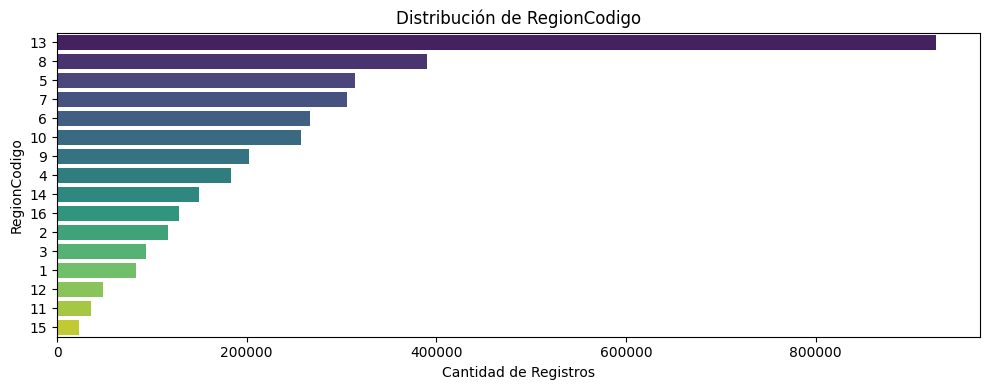

--------------------------------------------------
---- FRECUENCIAS: ComunaCodigo ----
ComunaCodigo
13110    59126
2101     54552
13401    52568
5101     49160
8301     46713
         ...  
8302      2760
5702      2628
5706      2556
5503      2508
8307      2400
Name: count, Length: 308, dtype: int64
Total de categorías únicas: 308

-> Gráfico omitido porque ComunaCodigo tiene demasiadas categorías (307).
--------------------------------------------------
---- FRECUENCIAS: ServicioSaludCodigo ----
ServicioSaludCodigo
16      305442
15      266695
10      236964
13      197707
14      190458
5       183812
7       155229
22      149560
21      138534
9       134001
17      128880
18      125927
3       116839
24      114639
6       111622
20      110334
12       97609
4        93754
19       85492
2        83199
11       76924
33       74091
23       69009
28       68738
29       64090
26       48768
8        40437
25       36100
None     25254
1        23084
Name: count, dtype: int64

C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


<Figure size 1000x400 with 0 Axes>

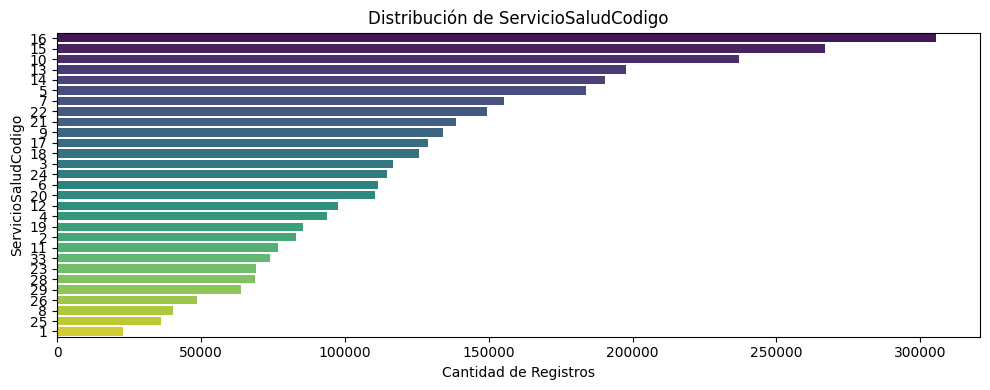

--------------------------------------------------
---- FRECUENCIAS: TipoEstablecimiento ----
TipoEstablecimiento
Servicio de Atención Primaria de Urgencia (SAPU)                         1343419
Hospital                                                                 1111185
Servicio de Urgencia Rural (SUR)                                          541086
Servicio de Atención Primaria de Urgencia de Alta Resolutividad (SAR)     507868
None                                                                       25254
Hospital                                                                   13184
Centro de Salud Familiar (CESFAM)                                           6725
Centro de Diagnóstico y Terapeútico (CDT)                                   4471
Name: count, dtype: int64
Total de categorías únicas: 8



C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


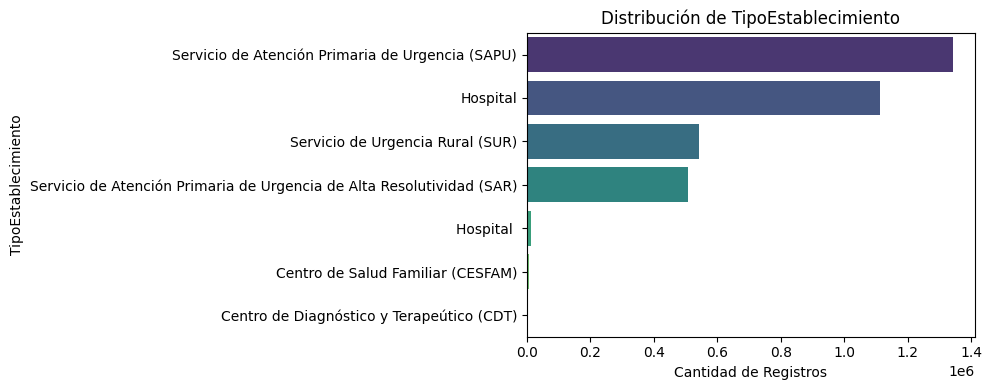

--------------------------------------------------
---- FRECUENCIAS: DependenciaAdministrativa ----
DependenciaAdministrativa
Municipal            2269457
Servicio de Salud    1203270
Municipal              28092
None                   25254
Delegados              20680
Otra Institución        6439
Name: count, dtype: int64
Total de categorías únicas: 6



C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


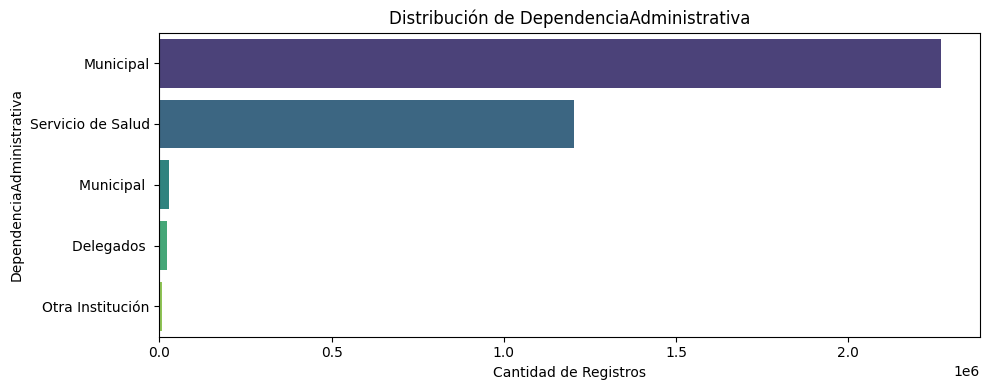

--------------------------------------------------
---- FRECUENCIAS: NivelAtencion ----
NivelAtencion
Primario      2991842
Terciario      522189
None            25254
Secundario      13907
Name: count, dtype: int64
Total de categorías únicas: 4



C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


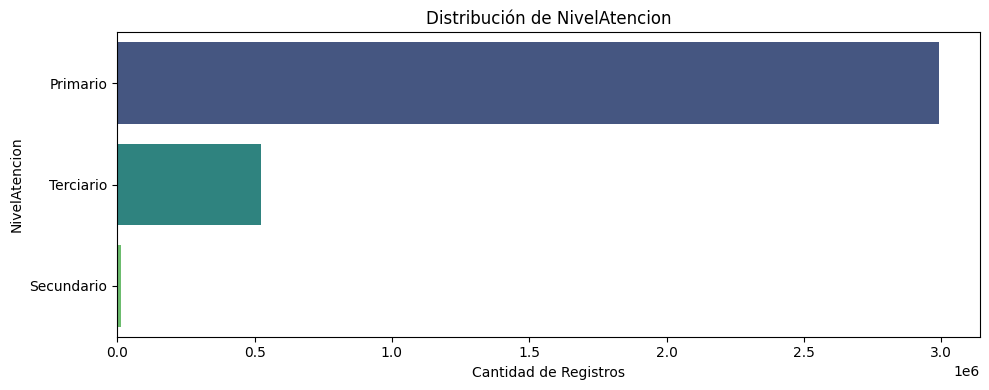

--------------------------------------------------
---- FRECUENCIAS: TipoUrgencia ----
TipoUrgencia
Urgencia Ambulatoria (SAPU)    1356658
Urgencia Hospitalaria (UEH)    1115354
Urgencia Ambulatoria (SUR)      541086
Urgencia ambulatoria (SAR)      456086
Urgencia Ambulatoria (SAR)       38543
None                             25254
Urgencia ambulatoria             10812
Urgencia Especializada            7791
Pendiente                         1224
No Aplica                          384
Name: count, dtype: int64
Total de categorías únicas: 10



C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


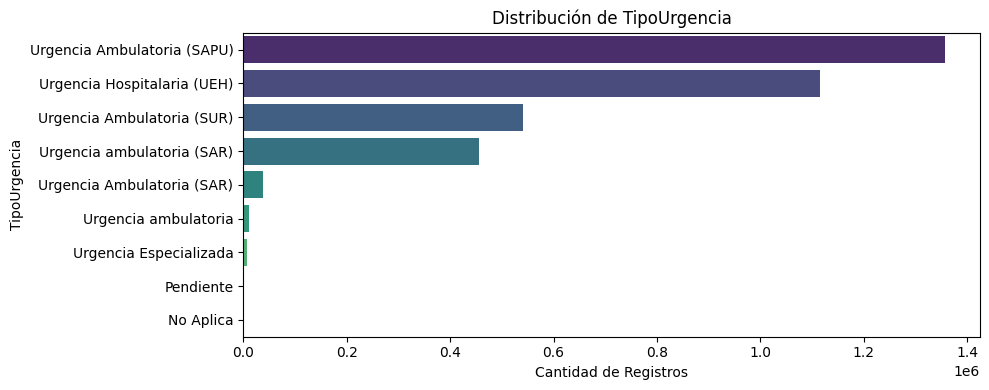

--------------------------------------------------
---- FRECUENCIAS: NivelComplejidad ----
NivelComplejidad
Baja Complejidad       2998410
Alta Complejidad        372826
Mediana Complejidad     153834
None                     25254
Completar                 2868
Name: count, dtype: int64
Total de categorías únicas: 5



C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


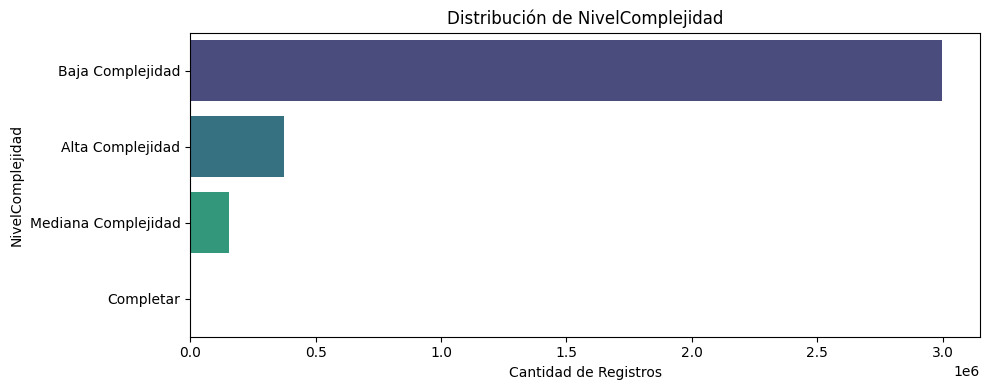

--------------------------------------------------
---- FRECUENCIAS: Causa ----
Causa
TOTAL CAUSA SISTEMA  RESPIRATORIO (J00-J98)                                                        342854
Influenza (J09-J11)                                                                                342854
Neumonía (J12-J18)                                                                                 342854
IRA Alta (J00-J06)                                                                                 342854
- Causas sistema respiratorio (J00-J98)                                                            342854
Otra causa respiratoria no contenidas en las categorías anteriores (J22; J30-J39, J47, J60-J98)    342854
Bronquitis/bronquiolitis aguda (J20-J21)                                                           342854
Crisis obstructiva bronquial (J40-J46)                                                             342854
TOTAL ATENCIONES POR COVID-19, Virus Identificado U07.1           

C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


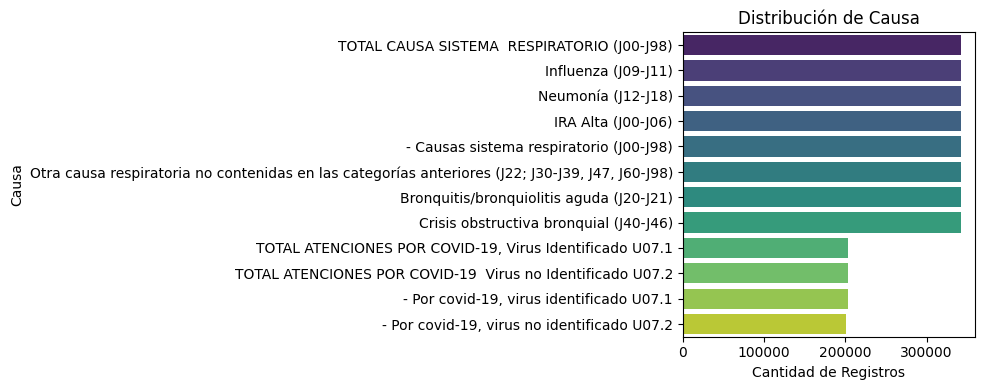

--------------------------------------------------


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas que queremos revisar
#cols_a_revisar = ['ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa']

# 1. Revisión de valores nulos
print("---- VALORES NULOS ----")
print(df.isnull().sum())
print("\n")

# 2. Iterar sobre las columnas para calcular frecuencias y graficarlas
for col in categoricas:
    print(f"---- FRECUENCIAS: {col} ----")
    # Ver cuántos datos hay de cada categoría
    frecuencias = df[col].value_counts(dropna=False)
    print(frecuencias)
    print(f"Total de categorías únicas: {df[col].nunique(dropna=False)}\n")
    
    # Gráficos si no son demasiadas categorías (para ServicioSaludCodigo puede que sean muchas)
    plt.figure(figsize=(10, 4))
    if df[col].nunique() < 50:
        sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribución de {col}')
        plt.xlabel('Cantidad de Registros')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print(f"-> Gráfico omitido porque {col} tiene demasiadas categorías ({df[col].nunique()}).")
    print("-" * 50)





In [11]:
# Eliminar todas las filas que contengan al menos un valor nulo (NaN) en cualquier columna
filas_previo = len(df)
print(f"Filas antes de eliminar nulos: {len(df)}")
df = df.dropna()
print(f"Filas después de eliminar nulos: {len(df)}")
print(f"Se eliminaron {filas_previo - len(df)} filas en total.")

Filas antes de eliminar nulos: 3553192
Filas después de eliminar nulos: 3527938
Se eliminaron 25254 filas en total.


In [12]:
#Comprobando si quedan nulos despues de la limpieza
import duckdb as db
con = db.connect()
con.register('df', df)
query = " select * from df where EstablecimientoCodigo is null"
result = con.execute(query).fetchdf()
print(result)
result.to_csv(f'../resultados/establecimientoNulo_DespuesLimpieza_{fecha_actual}.csv', index=False)

query = " select * from df where NivelComplejidad = '1.0'"
result = con.execute(query).fetchdf()
print(result)
result.to_csv(f'../resultados/NivelComplejidad123_{fecha_actual}.csv', index=False)

Empty DataFrame
Columns: [EstablecimientoCodigo, RegionCodigo, ComunaCodigo, ServicioSaludCodigo, TipoEstablecimiento, DependenciaAdministrativa, NivelAtencion, TipoUrgencia, NivelComplejidad, Anio, SemanaEstadistica, OrdenCausa, Causa, NumTotal]
Index: []
Empty DataFrame
Columns: [EstablecimientoCodigo, RegionCodigo, ComunaCodigo, ServicioSaludCodigo, TipoEstablecimiento, DependenciaAdministrativa, NivelAtencion, TipoUrgencia, NivelComplejidad, Anio, SemanaEstadistica, OrdenCausa, Causa, NumTotal]
Index: []


## Limpieza EstablecimientoCodigo, RegionCodigo, ComunaCodigo

In [13]:
print("--- REPORTE DE DATOS INVÁLIDOS ---")
columnas_interes = ['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo']
for col in columnas_interes:
    # 1. Hacemos una conversión "virtual" o temporal. 
    # Lo que no sea número se vuelve nulo temporalmente, pero el 'df' original queda intacto.
    simulacion = pd.to_numeric(df[col], errors='coerce')
    
    # 2. Comparamos: Buscamos filas que originalmente NO estaban vacías, 
    # pero que fallaron en la simulación matemática.
    datos_malos = df[(df[col].notnull()) & (simulacion.isnull())]
    
    # 3. Mostramos los resultados
    cantidad_errores = len(datos_malos)
    
    if cantidad_errores > 0:
        print(f"\n⚠️ PELIGRO: La columna '{col}' tiene {cantidad_errores} datos inválidos (no son números).")
        print("Aquí tienes los primeros 5 ejemplos de los datos problemáticos para que los veas:")
        # display() es perfecto en Jupyter para mostrar tablitas bonitas
        display(datos_malos[[col]].head()) 
    else:
        print(f"\n✅ La columna '{col}' está limpia. Todos sus textos son números válidos.")

--- REPORTE DE DATOS INVÁLIDOS ---

✅ La columna 'EstablecimientoCodigo' está limpia. Todos sus textos son números válidos.

✅ La columna 'RegionCodigo' está limpia. Todos sus textos son números válidos.

✅ La columna 'ComunaCodigo' está limpia. Todos sus textos son números válidos.


--- 

## Limpieza Anio, NivelComplejidad

In [14]:
from datetime import datetime

df['NC_Original'] = df['NivelComplejidad'].astype(str)


df['NivelComplejidad'] = df['NivelComplejidad'].astype(str).str.strip().str.title()

mapeo_rescate = {
    'Baja': 'Baja Complejidad', 'Bajacomplejidad': 'Baja Complejidad',
    'Mediana': 'Mediana Complejidad', 'Medianacomplejidad': 'Mediana Complejidad',
    'Alta': 'Alta Complejidad', 'Altacomplejidad': 'Alta Complejidad',
    'N/A': 'No Aplica', 'Na': 'No Aplica', 'Noaplica': 'No Aplica'
}
df['NivelComplejidad'] = df['NivelComplejidad'].replace(mapeo_rescate)

categorias_validas = ['Alta Complejidad', 'Mediana Complejidad', 'Baja Complejidad', 'No Aplica', 'Pendiente']
df.loc[~df['NivelComplejidad'].isin(categorias_validas), 'NivelComplejidad'] = 'Pendiente'

anio_actual = datetime.now().year

df = df.dropna(subset=['Anio'])
df['Anio'] = df['Anio'].astype(int)
df = df[(df['Anio'] >= 2014) & (df['Anio'] <= anio_actual)]

mask_cambio = df['NC_Original'] != df['NivelComplejidad']
reporte_cambios = df[mask_cambio].groupby(['NC_Original', 'NivelComplejidad']).size().reset_index(name='Casos')

print(f"Registros eliminados (por año inválido): {filas_iniciales - len(df) if 'filas_iniciales' in locals() else 'revisar'}")
print("\nDetalle de correcciones en Nivel de Complejidad:")
print(reporte_cambios.sort_values('Casos', ascending=False))

df = df.drop(columns=['NC_Original'])

Registros eliminados (por año inválido): revisar

Detalle de correcciones en Nivel de Complejidad:
  NC_Original NivelComplejidad  Casos
0   Completar        Pendiente   2868


In [15]:
def limpiar_datos_urgencia(df):
    print("Limpieza de NivelAtencion y TipoUrgencia...")
    
    df_limpio = df.copy()
    
    columnas_objetivo = ['NivelAtencion', 'TipoUrgencia']
    
    print("Nulos antes de limpiar:")
    print(df_limpio[columnas_objetivo].isnull().sum())
    
    # Limpieza
    for col in columnas_objetivo:
        # Rellenar nulos
        #df_limpio[col] = df_limpio[col].fillna('DESCONOCIDO')
        
        # Pasar a mayúsculas y quitar espacios extra
        df_limpio[col] = df_limpio[col].astype(str).str.strip().str.upper()

    # Nulos finales
    print("\nNulos después de limpiar:")
    print(df_limpio[columnas_objetivo].isnull().sum())
    print("-" * 50)
    
    return df_limpio

df = limpiar_datos_urgencia(df)
df.head().to_csv(f'../resultados/limpieza_rafa_{fecha_actual}.csv', index=False)

Limpieza de NivelAtencion y TipoUrgencia...
Nulos antes de limpiar:
NivelAtencion    0
TipoUrgencia     0
dtype: int64

Nulos después de limpiar:
NivelAtencion    0
TipoUrgencia     0
dtype: int64
--------------------------------------------------


## Estandarizacion Causa

In [16]:
df['Causa_Busqueda'] = df['Causa'].str.lower().str.replace(r'^- ', '', regex=True).str.strip()

mapeo_codigos = {
    'j00-j06': 'IRA alta (J00-J06)',
    'j09-j11': 'Influenza (J09-J11)',
    'j12-j18': 'Neumonía (J12-J18)',
    'j20-j21': 'Bronquitis/Bronquiolitis aguda (J20-J21)',
    'j40-j46': 'Crisis obstructiva bronquial (J40-J46)',
    'j22': 'Otra causa respiratoria (J22, J30-J39, J47, J60-J98)',
    'u07.1': 'COVID-19, virus identificado (U07.1)',
    'u07.2': 'COVID-19, virus no identificado (U07.2)'
}

def clasificar(texto):
    if 'total' in texto:
        return 'DESCARTAR'
    for codigo, nombre_oficial in mapeo_codigos.items():
        if codigo in texto:
            return nombre_oficial
    return 'DESCARTAR'

df['Causa_Final'] = df['Causa_Busqueda'].apply(clasificar)

# 3. Quedarnos solo con los datos limpios
df = df[df['Causa_Final'] != 'DESCARTAR'].copy()

# 4. Limpieza final de columnas (quitamos la auxiliar de búsqueda y renombramos)
df = df.drop(columns=['Causa', 'Causa_Busqueda'])
df = df.rename(columns={'Causa_Final': 'Causa'})

## Analisis Atipicos de NumTotal

1. Rango de Semanas: 1 a 53
   -> Registros fuera de rango (1-53): 0
2. Rango de OrdenCausa: 4 a 35
   -> Verificación: OK

----------------------------------------



C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\2767342904.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_por_causa = df.groupby('Causa').apply(detect_outliers_iqr)


3. Resumen de Límites y Cantidad de Outliers por Causa:
                                                    Limite_Sup  Cant_Outliers
Causa                                                                        
Bronquitis/Bronquiolitis aguda (J20-J21)                  74.0        19752.0
COVID-19, virus identificado (U07.1)                       0.0        10560.0
COVID-19, virus no identificado (U07.2)                    0.0         8863.0
Crisis obstructiva bronquial (J40-J46)                    21.0        25239.0
IRA alta (J00-J06)                                       357.5        10496.0
Influenza (J09-J11)                                        5.0        45174.0
Neumonía (J12-J18)                                        18.5        27460.0
Otra causa respiratoria (J22, J30-J39, J47, J60...        26.0        41983.0


C:\Users\Camilo\AppData\Local\Temp\ipykernel_5812\2767342904.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NumTotal', y='Causa', palette='viridis')


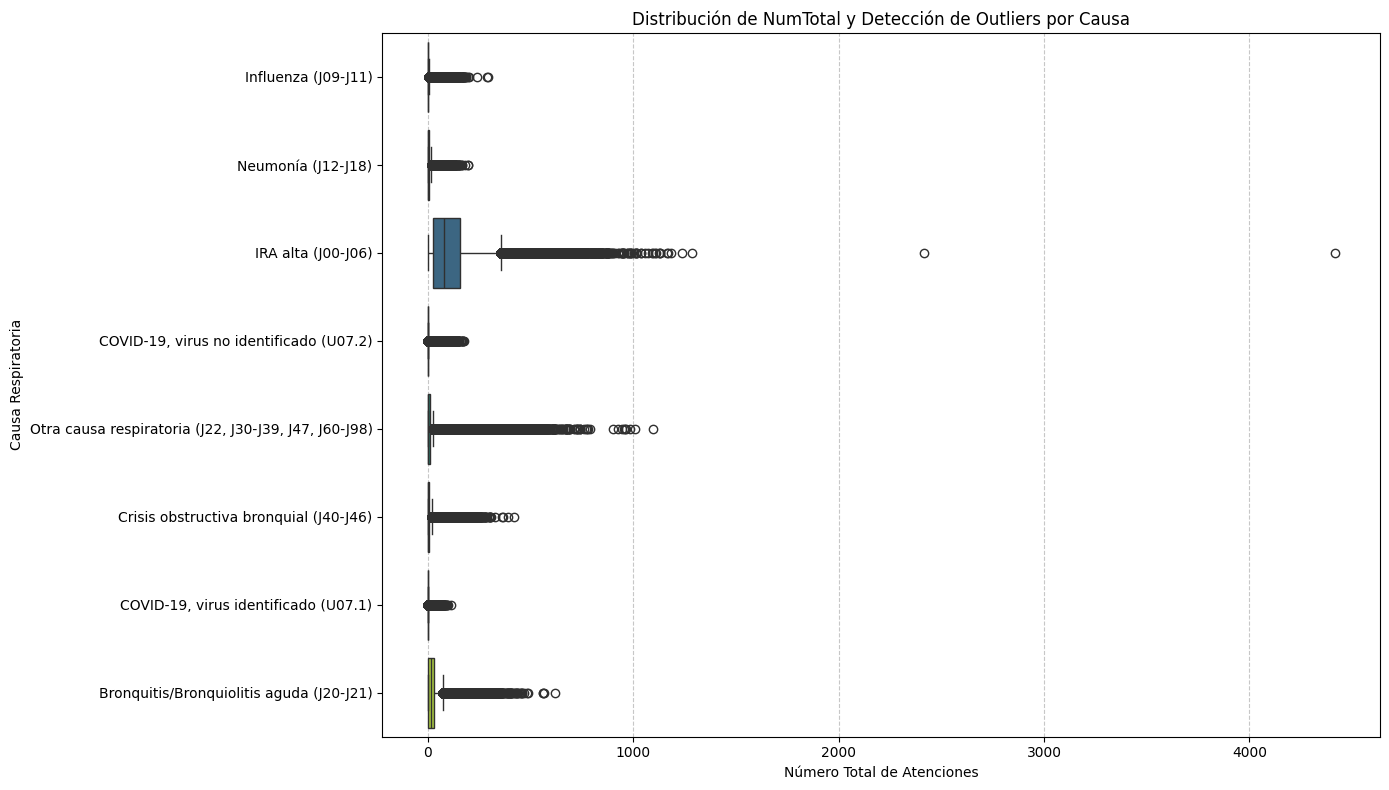


4. TOP 5 REGISTROS MÁS EXTREMOS (VALORES MÁS ALTOS):
         Anio  SemanaEstadistica               Causa  NumTotal
1985138  2022                 50  IRA alta (J00-J06)      4415
110494   2015                 43  IRA alta (J00-J06)      2415
3551088  2017                 11  IRA alta (J00-J06)      1285
227586   2023                 20  IRA alta (J00-J06)      1236
1090283  2022                  6  IRA alta (J00-J06)      1183


In [17]:
# ==================================================
# 1. VALIDACIÓN DE RANGOS LÓGICOS (NUEVO)
# ==================================================
# Chequeo de Semanas (1-53)
semanas_invalidas = df[(df['SemanaEstadistica'] < 1) | (df['SemanaEstadistica'] > 53)]
min_sem = df['SemanaEstadistica'].min()
max_sem = df['SemanaEstadistica'].max()

print(f"1. Rango de Semanas: {min_sem} a {max_sem}")
print(f"   -> Registros fuera de rango (1-53): {len(semanas_invalidas)}")

# Chequeo de OrdenCausa (3-35 según tus datos)
min_ord = df['OrdenCausa'].min()
max_ord = df['OrdenCausa'].max()
print(f"2. Rango de OrdenCausa: {min_ord} a {max_ord}")
print(f"   -> Verificación: {'OK' if min_ord >= 3 and max_ord <= 35 else 'REVISAR RANGOS'}")

print("\n" + "-"*40 + "\n")

# ==================================================
# 2. ANÁLISIS DE OUTLIERS (IQR)
# ==================================================
def detect_outliers_iqr(group):
    Q1 = group['NumTotal'].quantile(0.25)
    Q3 = group['NumTotal'].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    outliers = group[group['NumTotal'] > limite_superior]
    return pd.Series([limite_superior, len(outliers)], index=['Limite_Sup', 'Cant_Outliers'])

outliers_por_causa = df.groupby('Causa').apply(detect_outliers_iqr)

print("3. Resumen de Límites y Cantidad de Outliers por Causa:")
print(outliers_por_causa)

# ==================================================
# 3. VISUALIZACIÓN Y REGISTROS EXTREMOS
# ==================================================
# Gráfico Boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='NumTotal', y='Causa', palette='viridis')
plt.title('Distribución de NumTotal y Detección de Outliers por Causa')
plt.xlabel('Número Total de Atenciones')
plt.ylabel('Causa Respiratoria')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n4. TOP 5 REGISTROS MÁS EXTREMOS (VALORES MÁS ALTOS):")
print(df.sort_values(by='NumTotal', ascending=False)[['Anio', 'SemanaEstadistica', 'Causa', 'NumTotal']].head())

df.head(200).to_csv(f'../resultados/LimpiezaRenatoFinalAhoraSiQueSi_{fecha_actual}.csv', index=False)

## Matrices de correlacion

### Numerica

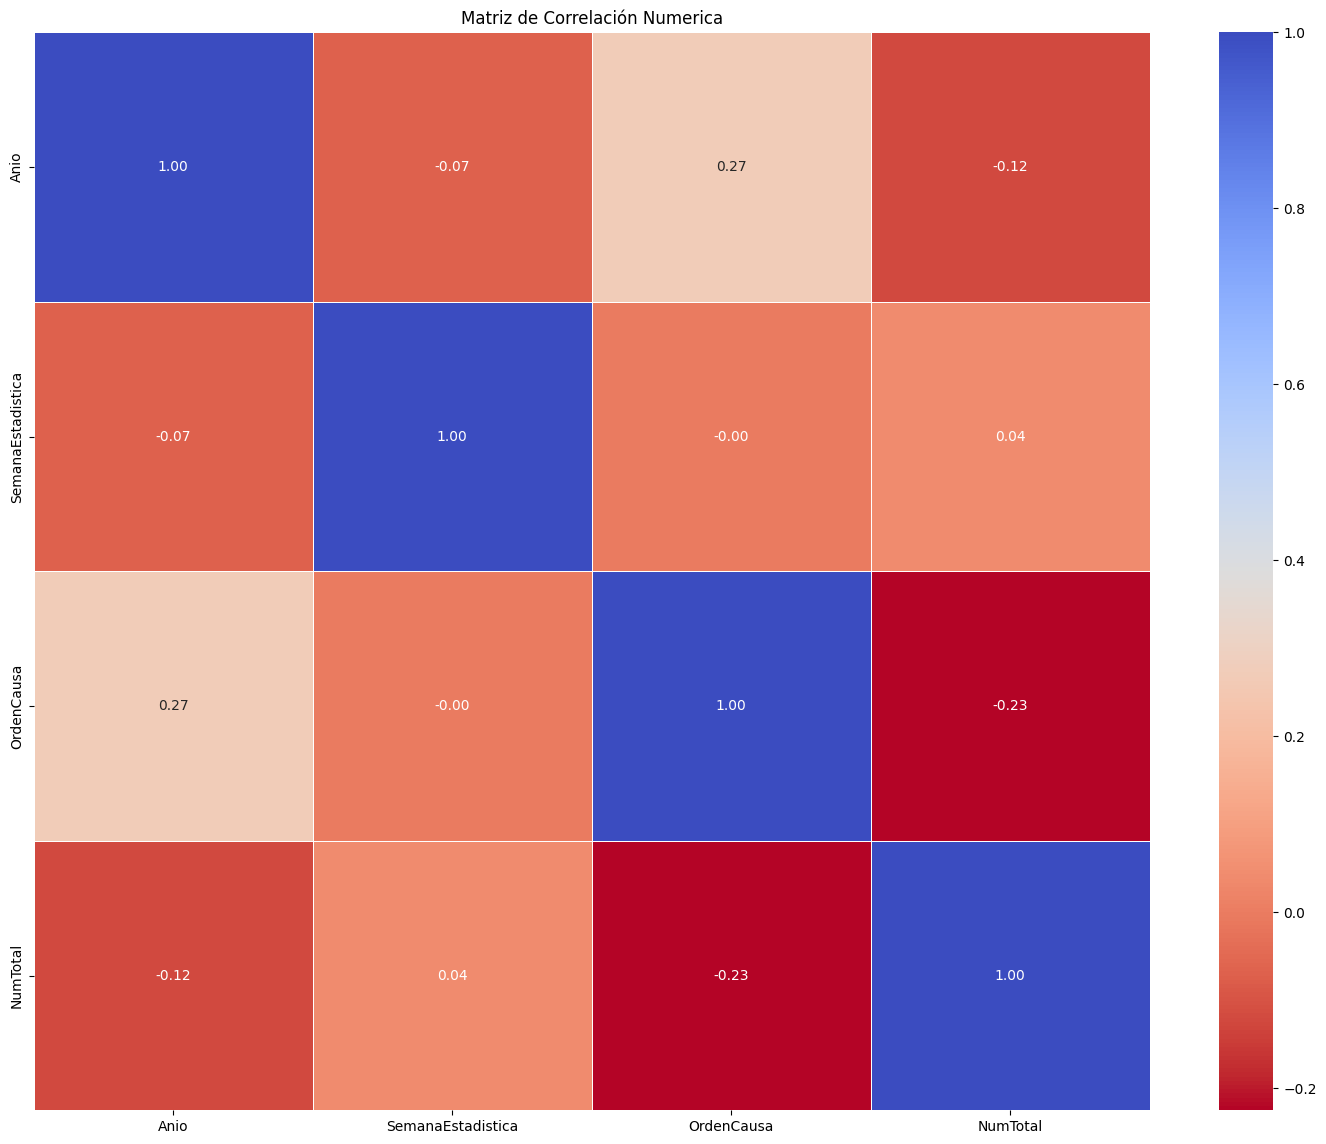

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas y booleanas (One-Hot) para la correlación
numerica_df = df.select_dtypes(include=['number', 'bool'])

# Generar la matriz de correlación (Ajustamos el tamaño para que quepan más variables)
plt.figure(figsize=(18, 14))
sns.heatmap(numerica_df.corr(), annot=True, cmap='coolwarm_r', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación Numerica')
plt.savefig(f'../resultados/matriz_correlacion_numerica_{fecha_actual}.png', dpi=300, bbox_inches='tight')  # Guardar la figura con alta resolución
plt.show()

### Categorica

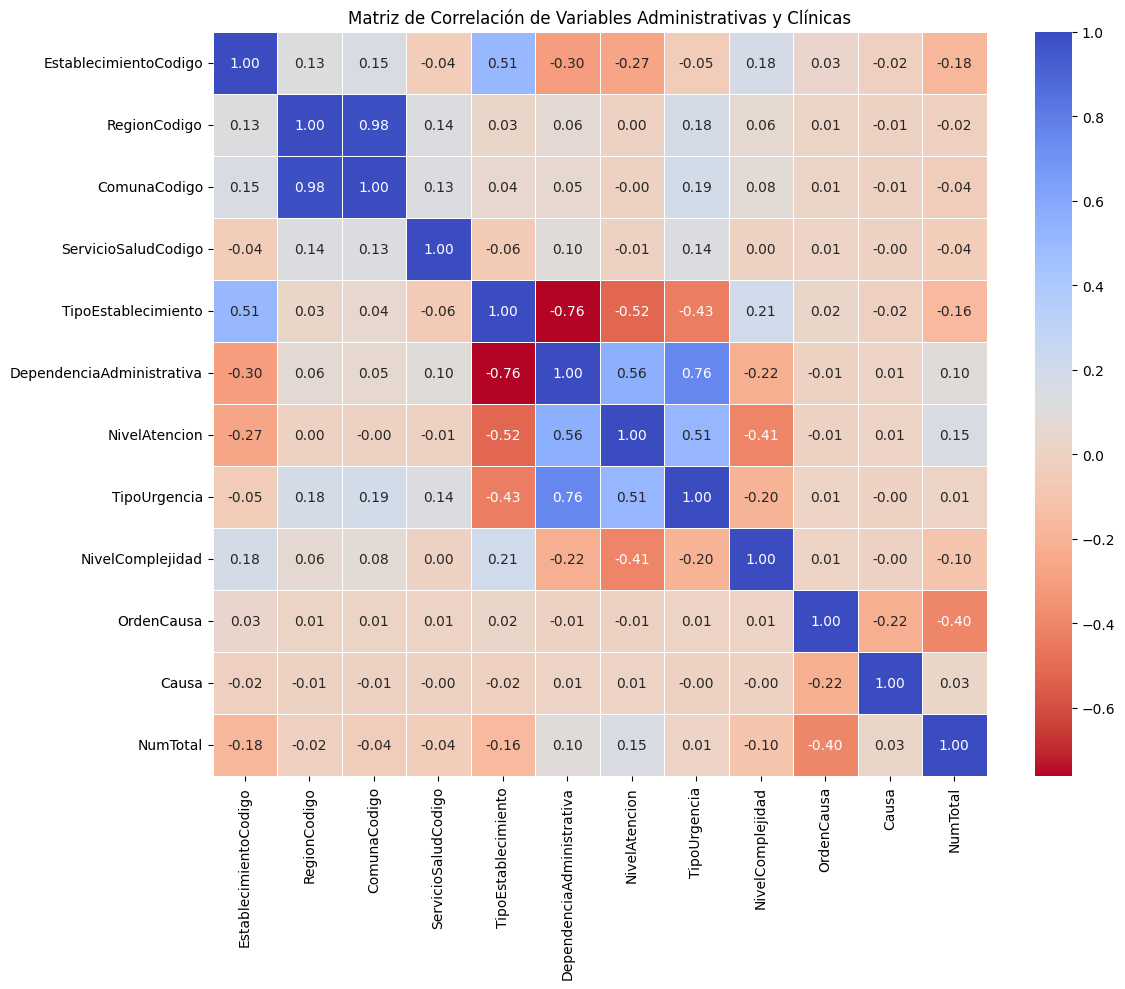

In [19]:
vars_matriz = [
    'EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 
    'ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa', 
    'NivelAtencion', 'TipoUrgencia', 'NivelComplejidad', 
    'OrdenCausa', 'Causa', 'NumTotal' # Agrego NumTotal para que la matriz tenga una meta
]

# 3. Preprocesamiento: Convertir categorías (strings) a números para poder correlacionar
df_corr = df[vars_matriz].copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# 4. Cálculo de la Matriz de Correlación (Spearman es mejor para categorías/orden)
corr_matrix = df_corr.corr(method='spearman')

# 5. Visualización con un Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm_r', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Administrativas y Clínicas')
plt.tight_layout()
plt.savefig(f'../resultados/matriz_correlacion_categorica_{fecha_actual}.png', dpi=300, bbox_inches='tight')  # Guardar la figura con alta resolución
plt.show()

# 3. Explore

### 2. Tratamiento de Variables Redundantes (Glosas vs Códigos)
Eliminamos las columnas de nombre ("Glosa") ya que contienen información redundante que aportaría colinealidad. Los códigos se forzan a tipo categórico (texto) para que no creen ponderaciones falsas en la correlación.

In [20]:
# Eliminar Glosas (nombres irrelevantes / colineales al código)
cols_glosa = ['EstablecimientoGlosa', 'RegionGlosa', 'ComunaGlosa', 'ServicioSaludGlosa']
df = df.drop(columns=cols_glosa, errors='ignore')

# Asegurar que los ID/Códigos sean texto y no números continuos
cols_codigo = ['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 'ServicioSaludCodigo']
for col_cod in cols_codigo:
    if col_cod in df.columns:
        df[col_cod] = df[col_cod].astype(str)

print("Columnas de código categorizadas correctamente. Columnas 'Glosa' eliminadas.")

Columnas de código categorizadas correctamente. Columnas 'Glosa' eliminadas.


### 3. Transformación de Variables Ordinales
Asignamos valores numéricos según su jerarquía intrínseca. 
- *NivelAtencion*: Primario (1), Secundario (2), Terciario (3)
- *NivelComplejidad*: Baja (1), Mediana (2), Alta (3)

In [21]:
# Diccionarios de mapeo para variables con jerarquía
mapa_atencion = {
    'PRIMARIO': 1,
    'SECUNDARIO': 2,
    'TERCIARIO': 3
}

mapa_complejidad = {
    'Baja Complejidad': 1,
    'Mediana Complejidad': 2,
    'Alta Complejidad': 3
}

# Aplicar los mapeos
if 'NivelAtencion' in df.columns:
    df['NivelAtencion'] = df['NivelAtencion'].map(mapa_atencion)
    
if 'NivelComplejidad' in df.columns:
    df['NivelComplejidad'] = df['NivelComplejidad'].map(mapa_complejidad)

print("Variables ordinales transformadas:")
print(df[['NivelAtencion', 'NivelComplejidad']].head(3))

Variables ordinales transformadas:
   NivelAtencion  NivelComplejidad
3              1               1.0
4              1               1.0
5              3               3.0


### 4. Transformación de Variables Nominales (One-Hot Encoding)
Para aquellas categorías que no tienen orden matemático (`TipoEstablecimiento`, `DependenciaAdministrativa`, `TipoUrgencia`, `Causa`).
Para la columna `Causa`, agruparemos las causas de menor frecuencia bajo la categoría "Otras" para evitar una explosión de columnas dispersas.

In [22]:
# Tratamiento de columna 'Causa' (agrupar causas poco comunes en 'Otras')
if 'Causa' in df.columns:
    # Determinamos el límite: nos quedaremos solo con causas que representen al menos el ~5% de los datos (o el top 5)
    frecuencias_causas = df['Causa'].value_counts(normalize=True)
    # Por ejemplo, conservamos causas que superen el 3% de los registros
    causas_importantes = frecuencias_causas[frecuencias_causas > 0.03].index
    
    # Reemplazar con 'Otras_Causas' a los que no estén en `causas_importantes`
    df['Causa'] = df['Causa'].apply(lambda x: x if x in causas_importantes else 'Otras_Causas')

# Aplicar One-Hot Encoding
columnas_nominales = ['TipoEstablecimiento', 'DependenciaAdministrativa', 'TipoUrgencia', 'Causa']
# Filtramos para asegurar que las columnas existan en el df actual antes de get_dummies
columnas_nominales_validas = [col for col in columnas_nominales if col in df.columns]

# Generamos las columnas One-Hot. Con drop_first=True evitamos mínima colinealidad extra si prefieres. 
# Dejaremos drop_first=False para fácil interpretabilidad en la correlación.
df = pd.get_dummies(df, columns=columnas_nominales_validas, drop_first=False)

print(f"Dimensiones del DataFrame después de One-Hot Encoding: {df.shape}")

Dimensiones del DataFrame después de One-Hot Encoding: (2444377, 38)


In [23]:
fecha_actual = datetime.now().strftime("%Y-%m-%d-%H%M%S")

df.head(100).to_csv(f'../resultados/DatosFormatoNumerico_{fecha_actual}.csv', index=False)

In [24]:


df.to_parquet(f'./dataset_limpios/at_urg_respiratorio_limpio_{fecha_actual}.parquet', index=False, engine='fastparquet')

## Análisis de Series Temporales (Estacionalidad, Tendencia, Estacionariedad)
A continuación, cargaremos los datos limpios y crearemos una fecha a partir de `Anio` y `SemanaEstadistica`. Luego, analizaremos la serie temporal de `NumTotal`.

In [25]:
%pip install pandas numpy matplotlib statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


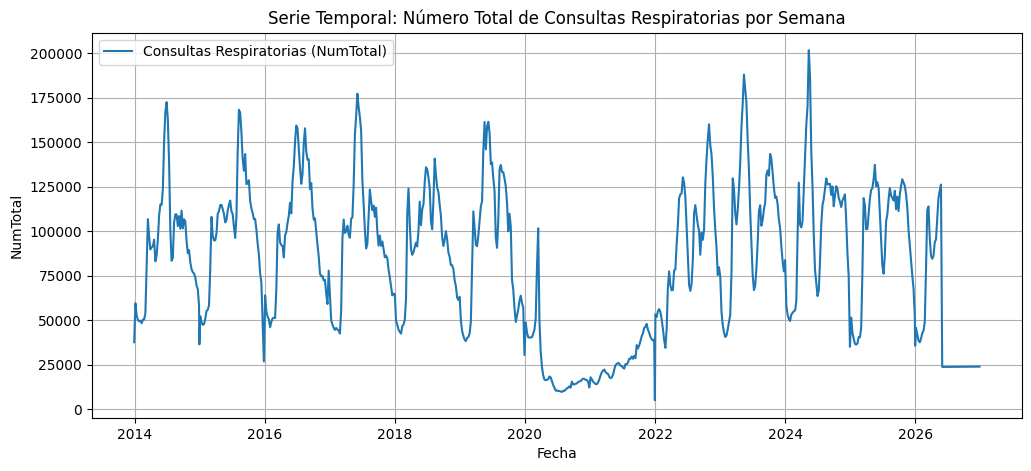

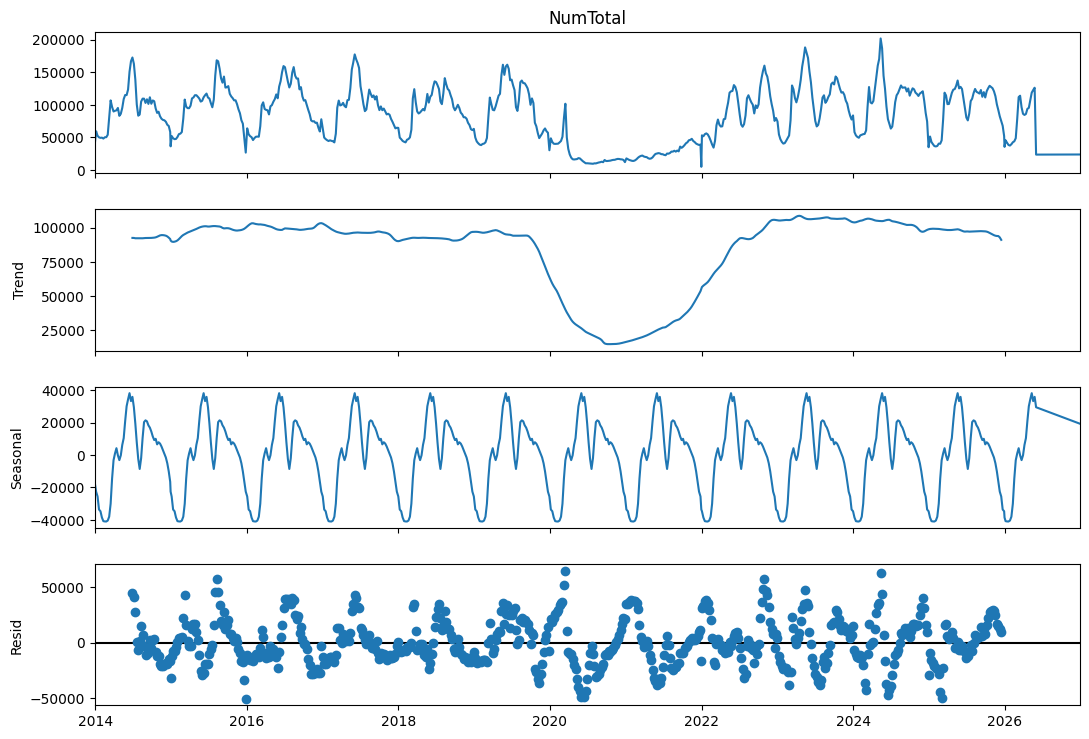

--- Prueba ADF (Augmented Dickey-Fuller) ---
Estadístico ADF: -5.194454853485353
p-value: 9.024182834452861e-06
Valores Críticos:
   1%: -3.440434903803665
   5%: -2.865989920612213
   10%: -2.569139761751388

Conclusión: Rechazamos la hipótesis nula. La serie es ESTACIONARIA.


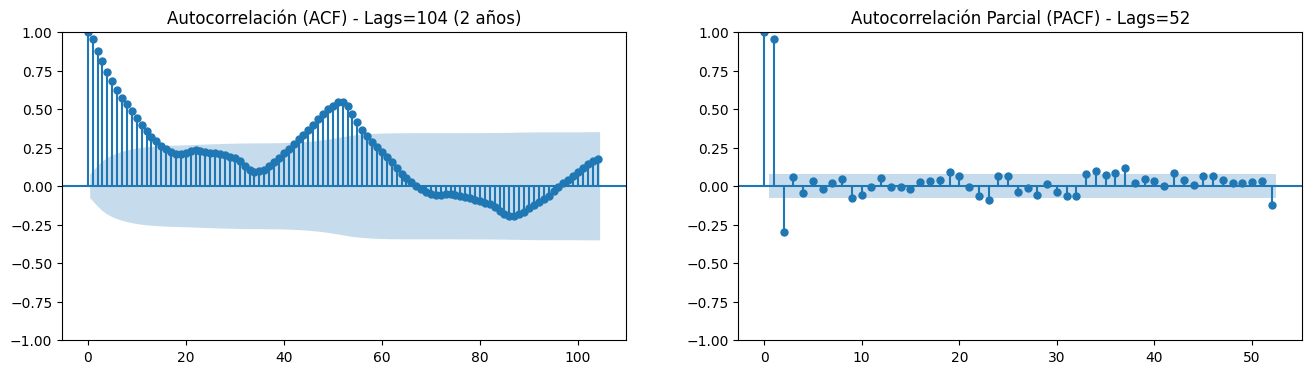

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime

# 1. Cargar el dataset limpio
df = pd.read_parquet('dataset_limpios/at_urg_respiratorio_limpio.parquet')

# 2. Crear una columna de fecha a partir de Anio y SemanaEstadistica
# Usamos el lunes de cada semana como representación de la fecha
def get_date_from_iso_week(year, week):
    # Formato '%G-W%V-%u' -> %G año ISO, %V semana ISO, %u día de la semana (1-7)
    date_str = f'{year}-W{week:02d}-1' 
    try:
        return datetime.strptime(date_str, '%G-W%V-%u')
    except ValueError:
        # Algunos años pueden tener 53 semanas, si hay error usamos el ultimo dia del año
        return datetime(year, 12, 31)

df['Fecha'] = df.apply(lambda row: get_date_from_iso_week(int(row['Anio']), int(row['SemanaEstadistica'])), axis=1)

# Agrupar por fecha y sumar el NumTotal
ts_df = df.groupby('Fecha')['NumTotal'].sum().reset_index()
ts_df.set_index('Fecha', inplace=True)
ts_df.sort_index(inplace=True)

# 3. Visualización de la Serie Temporal
plt.figure(figsize=(12, 5))
plt.plot(ts_df.index, ts_df['NumTotal'], label='Consultas Respiratorias (NumTotal)')
plt.title('Serie Temporal: Número Total de Consultas Respiratorias por Semana')
plt.xlabel('Fecha')
plt.ylabel('NumTotal')
plt.legend()
plt.grid(True)
plt.show()

# 4. Descomposición de la serie (Tendencia, Estacionalidad, Ruido)
# Asumimos una estacionalidad anual. Al tener datos semanales, el periodo es 52
decomposition = seasonal_decompose(ts_df['NumTotal'], model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 5. Prueba de Estacionariedad (Test de Dickey-Fuller Aumentado - ADF)
def adf_test(series):
    result = adfuller(series.dropna())
    print('--- Prueba ADF (Augmented Dickey-Fuller) ---')
    print('Estadístico ADF:', result[0])
    print('p-value:', result[1])
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    if result[1] <= 0.05:
        print("\nConclusión: Rechazamos la hipótesis nula. La serie es ESTACIONARIA.")
    else:
        print("\nConclusión: No podemos rechazar la hipótesis nula. La serie NO ES ESTACIONARIA.")

adf_test(ts_df['NumTotal'])

# 6. Gráficos ACF y PACF para determinar parámetros pdq de modelos ARIMA/SARIMA
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts_df['NumTotal'].dropna(), ax=axes[0], lags=104, title='Autocorrelación (ACF) - Lags=104 (2 años)')
plot_pacf(ts_df['NumTotal'].dropna(), ax=axes[1], lags=52, title='Autocorrelación Parcial (PACF) - Lags=52')
plt.show()


# Modelado de Series Temporales: SARIMA

En base al análisis exploratorio previo (test ADF estacionario, pero con fuerte estacionalidad anual en enfermedades respiratorias), aplicaremos el modelo **SARIMA** (Seasonal Autoregressive Integrated Moving Average).

Separaremos la serie temporal dejando el último año (52 semanas) como conjunto de prueba (test set) para evaluar qué tan bien el modelo puede predecir "el futuro" comparado con los datos reales que ya tenemos.

In [27]:
%pip install pandas numpy matplotlib statsmodels scikit-learn pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar y preparar los datos (mismo proceso que en explore)
df = pd.read_parquet('dataset_limpios/at_urg_respiratorio_limpio.parquet')

def get_date_from_iso_week(year, week):
    date_str = f'{year}-W{week:02d}-1' 
    try:
        return datetime.strptime(date_str, '%G-W%V-%u')
    except ValueError:
        return datetime(year, 12, 31)

df['Fecha'] = df.apply(lambda row: get_date_from_iso_week(int(row['Anio']), int(row['SemanaEstadistica'])), axis=1)

ts_df = df.groupby('Fecha')['NumTotal'].sum().reset_index()
ts_df.set_index('Fecha', inplace=True)
ts_df.sort_index(inplace=True)

# Asignar frecuencia semanal explícita para evitar advertencias de Statsmodels
ts_df = ts_df.asfreq('W-MON')
# Rellenar valores nulos (si hubiera semanas omitidas) con el método ffill (forward fill) o interpolación lineal
ts_df['NumTotal'] = ts_df['NumTotal'].interpolate(method='linear')

print("Datos preparados. Frecuencia de la serie indexada:\n", ts_df.head(2))

Datos preparados. Frecuencia de la serie indexada:
             NumTotal
Fecha               
2013-12-30   37571.0
2014-01-06   59421.0


In [29]:
# 2. Dividir los datos en Entrenamiento (Train) y Prueba (Test)
# Entrenar desde el 2022 hasta el 2025, y testear solo con el año 2026.

train = ts_df[(ts_df.index.year >= 2014) & (ts_df.index.year <= 2024)]
test = ts_df[ts_df.index.year == 2025]

test_size = len(test)

print(f"Fechas de Entrenamiento: desde {train.index.min().date()} hasta {train.index.max().date()}")
print(f"Fechas de Prueba (Test): desde {test.index.min().date()} hasta {test.index.max().date()}")
print(f"Semanas en entrenamiento: {len(train)}")
print(f"Semanas en prueba (test): {test_size}")

Fechas de Entrenamiento: desde 2014-01-06 hasta 2024-12-30
Fechas de Prueba (Test): desde 2025-01-06 hasta 2025-12-29
Semanas en entrenamiento: 574
Semanas en prueba (test): 52


In [30]:
# 3. Entrenamiento del Modelo SARIMA
# Parámetros:
# order=(p, d, q): Componente no estacional. d=0 porque confirmamos estacionariedad con test ADF. p=1 y q=1 como punto de partida clásico.
# seasonal_order=(P, D, Q, m): Componente estacional. m=52 (semanas en el año). D=1 para diferenciar la estacionalidad anual.
print("Entrenando modelo SARIMA, esto puede tardar un momento...")

model = SARIMAX(train['NumTotal'], 
                order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 52),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print("¡Entrenamiento finalizado!")
print(results.summary())

Entrenando modelo SARIMA, esto puede tardar un momento...
¡Entrenamiento finalizado!
                                     SARIMAX Results                                      
Dep. Variable:                           NumTotal   No. Observations:                  574
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 52)   Log Likelihood               -4964.816
Date:                            Wed, 17 Jun 2026   AIC                           9939.633
Time:                                    13:44:13   BIC                           9960.375
Sample:                                01-06-2014   HQIC                          9947.795
                                     - 12-30-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9615      0.

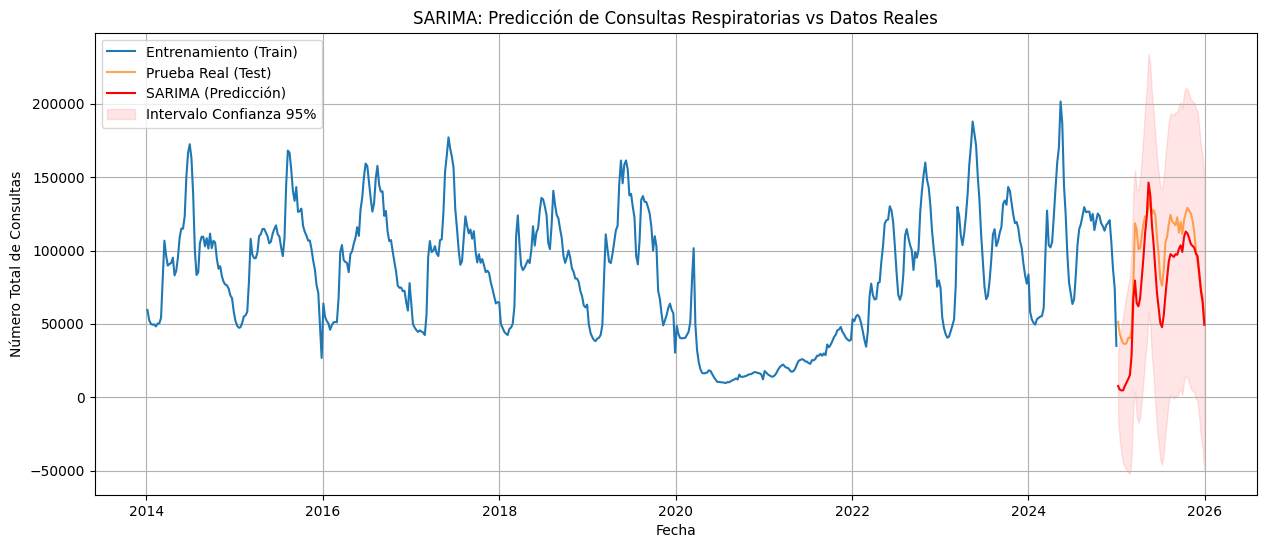

In [31]:
# 4. Predicción y Visualización

# Predecir los próximos 'test_size' pasos (las 52 semanas del set de testeo)
predictions = results.get_forecast(steps=test_size)
pred_mean = predictions.predicted_mean
pred_ci = predictions.conf_int() # Intervalos de confianza

plt.figure(figsize=(15, 6))

# Graficar Train
plt.plot(train.index, train['NumTotal'], label='Entrenamiento (Train)')
# Graficar Test real
plt.plot(test.index, test['NumTotal'], label='Prueba Real (Test)', alpha=0.7)
# Graficar Predicción
plt.plot(pred_mean.index, pred_mean, color='red', label='SARIMA (Predicción)')

# Sombreado de Intervalos de Confianza (95%)
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1], color='red', alpha=0.1, label='Intervalo Confianza 95%')

plt.title('SARIMA: Predicción de Consultas Respiratorias vs Datos Reales')
plt.xlabel('Fecha')
plt.ylabel('Número Total de Consultas')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# 5. Evaluación del Modelo (Métricas)

# Para calcular el error solo comparamos sobre las fechas en donde tenemos test reales (ignoramos NaNs)
test_y = test['NumTotal'].dropna()
pred_clean = pred_mean.loc[test_y.index]

rmse = np.sqrt(mean_squared_error(test_y, pred_clean))
mae = mean_absolute_error(test_y, pred_clean)
mape = mean_absolute_percentage_error(test_y, pred_clean)

print("=== Métricas de Rendimiento sobre Set de Prueba ===")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Error Absoluto Medio (MAE):               {mae:.2f}")
print(f"Error Absoluto Porcentual (MAPE):         {mape*100:.2f}%")

=== Métricas de Rendimiento sobre Set de Prueba ===
Raíz del Error Cuadrático Medio (RMSE): 25100.33
Error Absoluto Medio (MAE):               21794.44
Error Absoluto Porcentual (MAPE):         28.13%


Probando clusterizacion de la serie de tiempo

1. Cargando datos desde Parquet...
2. Creando matriz temporal...
3. Aplicando Clustering con K=4...
4. Generando visualizaciones maestras...



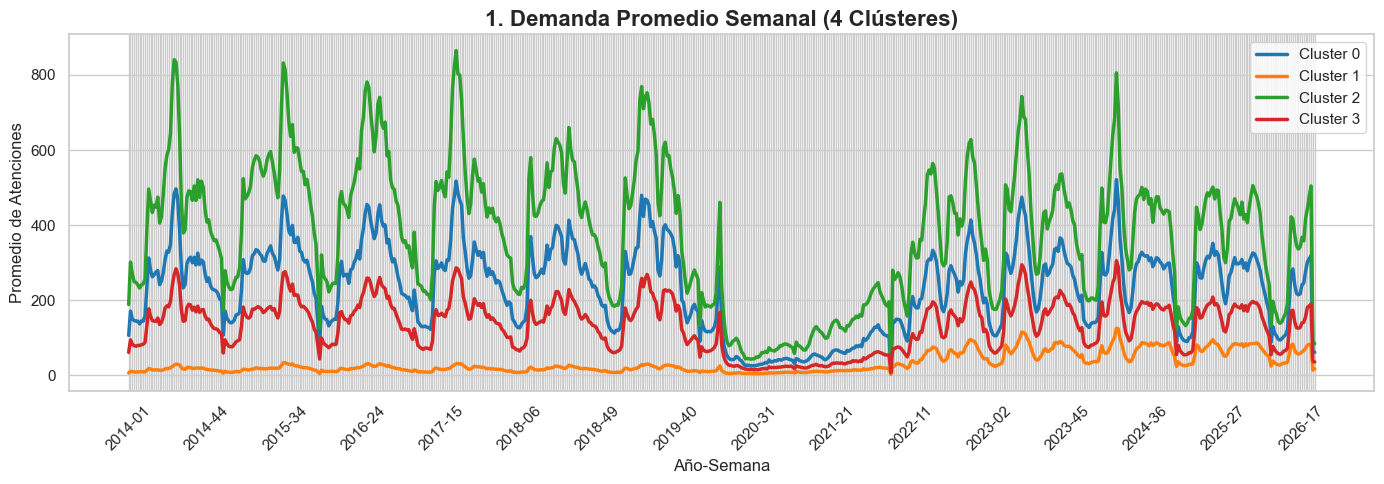

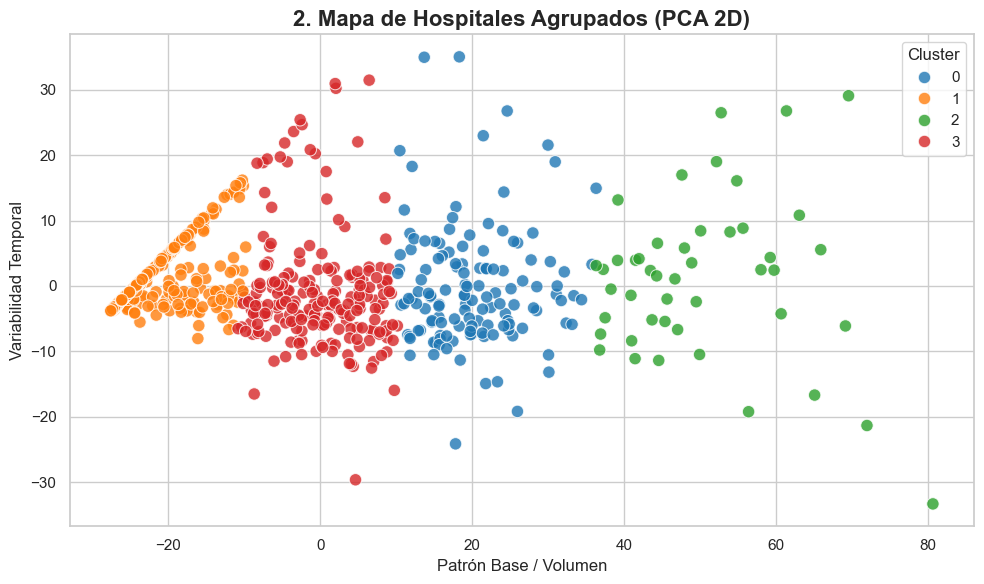

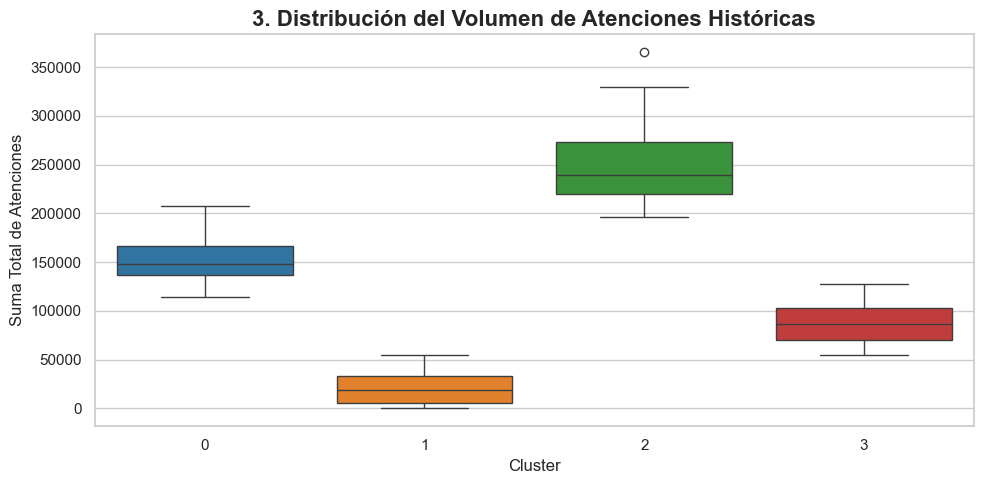

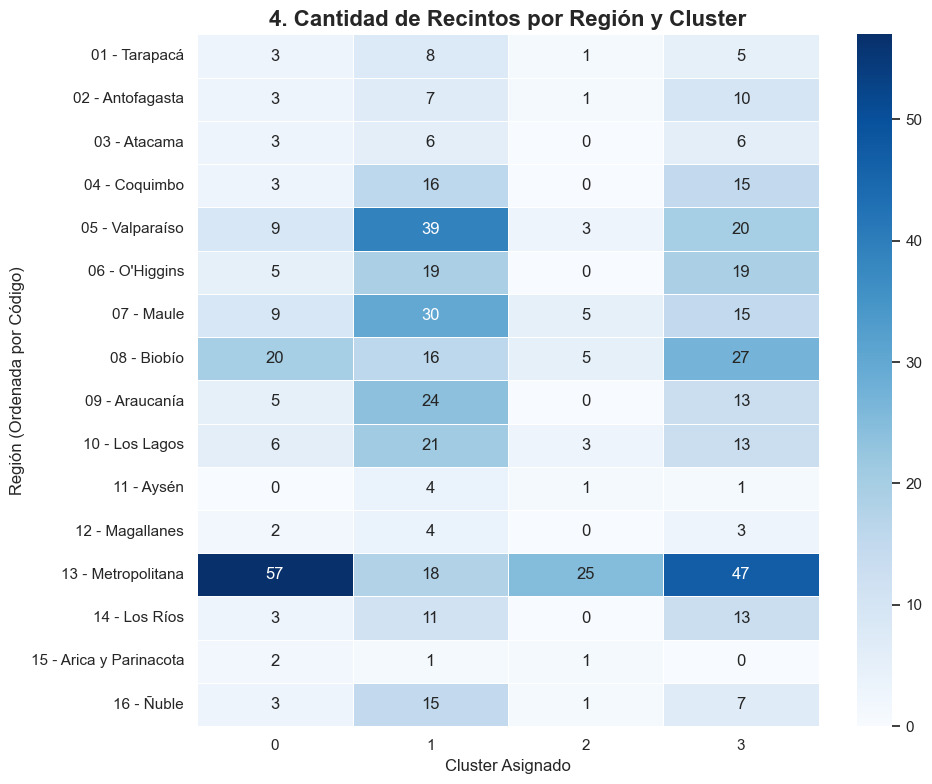

¡Las 4 visualizaciones han sido generadas con éxito!


In [36]:
# ==============================================================================
# PROYECTO: CLUSTERING (K=4) Y VISUALIZACIÓN CON REGIONES ORDENADAS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración visual y paleta de 4 colores
sns.set_theme(style="whitegrid")
colores_4 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Azul, Naranja, Verde, Rojo

print("1. Cargando datos desde Parquet...")
# IMPORTANTE: Reemplaza con el nombre de tu archivo Parquet
#df = pd.read_parquet('tu_archivo_datos.parquet', engine='pyarrow')

# Preparar periodo y pivotar datos
df['Periodo'] = df['Anio'].astype(str) + "-" + df['SemanaEstadistica'].astype(str).str.zfill(2)
print("2. Creando matriz temporal...")
df_pivot = df.pivot_table(index='EstablecimientoCodigo', columns='Periodo', values='NumTotal', aggfunc='sum').fillna(0)

# ==============================================================================
# 3. APLICACIÓN DE CLUSTERING (K = 4)
# ==============================================================================
print("3. Aplicando Clustering con K=4...")
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pivot)

# Forzamos los 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df_pivot['Cluster'] = kmeans.fit_predict(df_scaled)

# ==============================================================================
# 4. ENRIQUECER DATOS (VOLUMEN TOTAL Y REGIONES)
# ==============================================================================
# A. Calcular el volumen total histórico de cada recinto
columnas_temporales = df_pivot.drop(columns=['Cluster']).columns
df_pivot['Volumen_Total'] = df_pivot[columnas_temporales].sum(axis=1)

# B. Rescatar la región y asegurar que sea numérica para que se ordene bien
est_region = df[['EstablecimientoCodigo', 'RegionCodigo']].drop_duplicates(subset=['EstablecimientoCodigo']).set_index('EstablecimientoCodigo')
df_pivot = df_pivot.join(est_region)

# Convertir explícitamente a número para garantizar el orden de 1 a 16
df_pivot['RegionCodigo'] = pd.to_numeric(df_pivot['RegionCodigo'], errors='coerce').fillna(0).astype(int)

# Diccionario de regiones
mapa_regiones = {
    1: 'Tarapacá', 2: 'Antofagasta', 3: 'Atacama', 4: 'Coquimbo',
    5: 'Valparaíso', 6: 'O\'Higgins', 7: 'Maule', 8: 'Biobío',
    9: 'Araucanía', 10: 'Los Lagos', 11: 'Aysén', 12: 'Magallanes',
    13: 'Metropolitana', 14: 'Los Ríos', 15: 'Arica y Parinacota', 16: 'Ñuble'
}

df_pivot.to_csv(f'../resultados/Clustering_4_Clusters_{fecha_actual}.csv', index=True)

# ==============================================================================
# 5. VISUALIZACIONES MAESTRAS
# ==============================================================================
print("4. Generando visualizaciones maestras...\n")

# --- GRÁFICO 1: Curvas Promedio ---
plt.figure(figsize=(14, 5))
cluster_means = df_pivot.groupby('Cluster')[columnas_temporales].mean()

for i in range(4):
    plt.plot(cluster_means.columns, cluster_means.iloc[i], label=f'Cluster {i}', color=colores_4[i], linewidth=2.5)

plt.title('1. Demanda Promedio Semanal (4 Clústeres)', fontsize=16, fontweight='bold')
plt.xlabel('Año-Semana', fontsize=12)
plt.ylabel('Promedio de Atenciones', fontsize=12)
plt.xticks(rotation=45)
ax = plt.gca()
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % max(1, len(columnas_temporales)//15) != 0: label.set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: PCA (Mapa de puntos) ---
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=componentes, columns=['Componente 1', 'Componente 2'])
df_pca['Cluster'] = df_pivot['Cluster'].values

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Componente 1', y='Componente 2', hue='Cluster', palette=colores_4, data=df_pca, s=80, alpha=0.8)
plt.title('2. Mapa de Hospitales Agrupados (PCA 2D)', fontsize=16, fontweight='bold')
plt.xlabel('Patrón Base / Volumen')
plt.ylabel('Variabilidad Temporal')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# --- GRÁFICO 3: Boxplot de Volumen Total ---
plt.figure(figsize=(10, 5))
sns.boxplot(x='Cluster', y='Volumen_Total', data=df_pivot, hue='Cluster', palette=colores_4, legend=False)
plt.title('3. Distribución del Volumen de Atenciones Históricas', fontsize=16, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Suma Total de Atenciones')
plt.tight_layout()
plt.show()

# --- GRÁFICO 4: Mapa de Calor Regional (AHORA ORDENADO POR CÓDIGO) ---
# Hacemos la tabla cruzada usando el código numérico para que pandas lo ordene del 1 al 16
crosstab_geo = pd.crosstab(df_pivot['RegionCodigo'], df_pivot['Cluster'])

# Ahora que está ordenado numéricamente, le cambiamos el nombre a las filas (índice)
# para que muestre "01 - Tarapacá", "13 - Metropolitana", etc.
nombres_formateados = [f"{cod:02d} - {mapa_regiones.get(cod, 'Desconocida')}" for cod in crosstab_geo.index]
crosstab_geo.index = nombres_formateados

plt.figure(figsize=(10, 8)) # Un poco más alto para que quepan bien las 16 regiones
sns.heatmap(crosstab_geo, annot=True, fmt='d', cmap='Blues', linewidths=.5)
plt.title('4. Cantidad de Recintos por Región y Cluster', fontsize=16, fontweight='bold')
plt.xlabel('Cluster Asignado')
plt.ylabel('Región (Ordenada por Código)')
plt.tight_layout()
plt.show()

print("¡Las 4 visualizaciones han sido generadas con éxito!")

1. Entrenando Árbol de Decisión para extraer reglas...


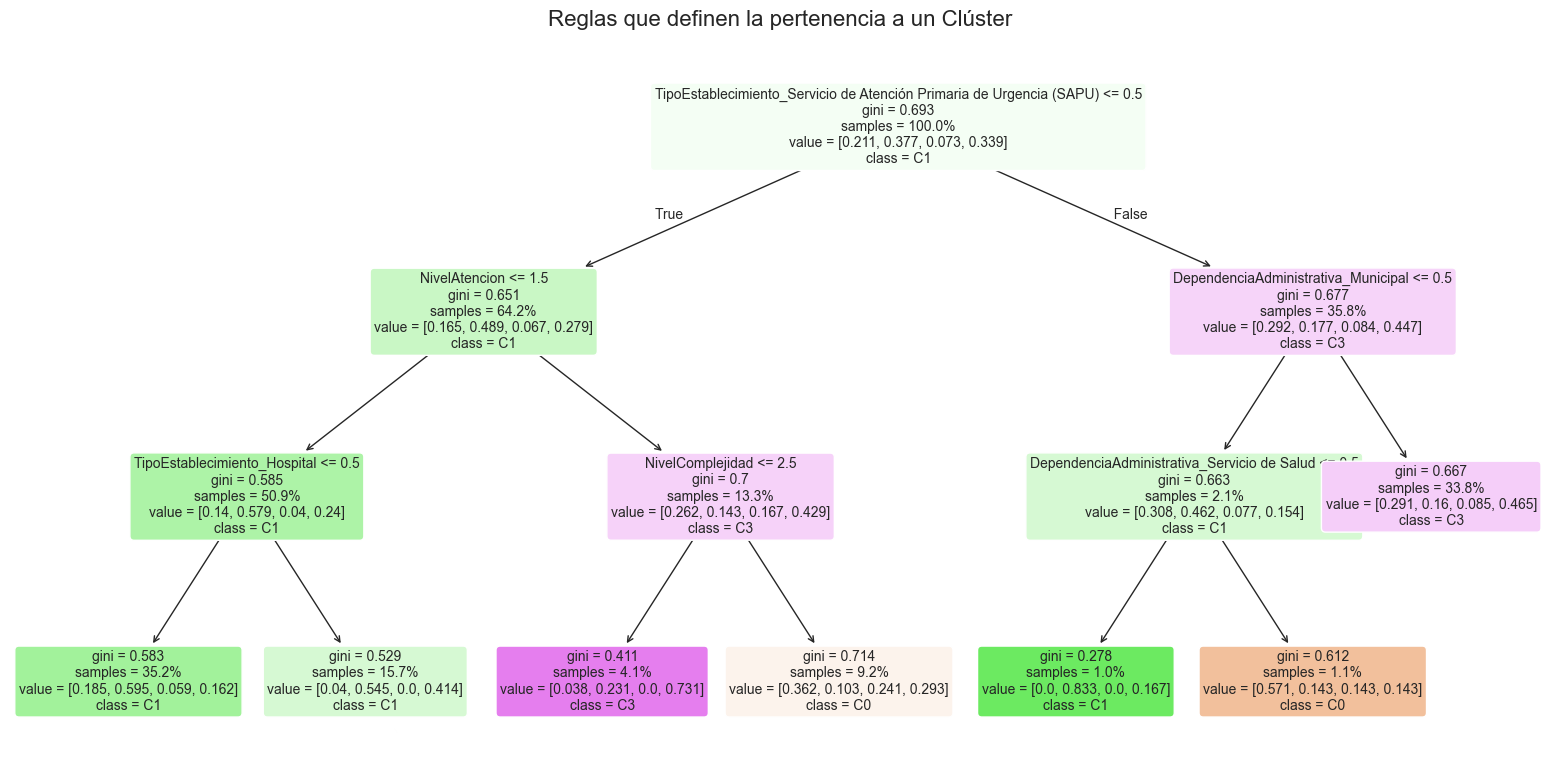

2. Entrenando Random Forest para Importancia de Variables...


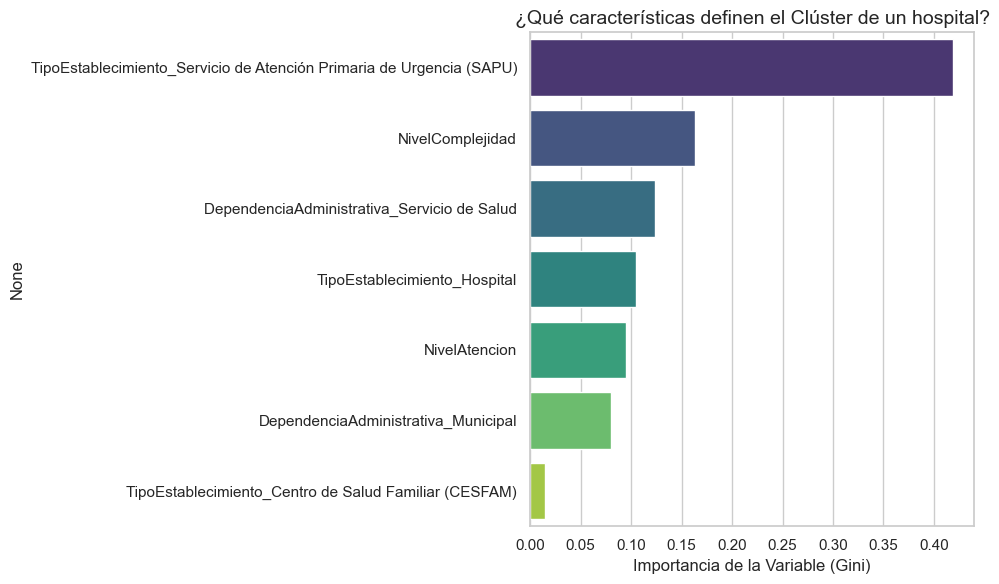

In [34]:
# ==============================================================================
# INTERPRETABILIDAD: ¿POR QUÉ UN HOSPITAL ESTÁ EN CADA CLUSTER?
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# 1. PREPARAR LOS DATOS "DESCRIPTIVOS" DEL HOSPITAL
# En lugar de usar las semanas, usaremos las columnas estáticas que definen al recinto.
# Rescatamos el primer registro de cada hospital de tu dataset original (df)
columnas_descriptivas = [
    'EstablecimientoCodigo', 'NivelAtencion', 'NivelComplejidad', 
    'TipoEstablecimiento_Servicio de Atención Primaria de Urgencia (SAPU)',
    'TipoEstablecimiento_Hospital', 'TipoEstablecimiento_Centro de Salud Familiar (CESFAM)',
    'DependenciaAdministrativa_Municipal', 'DependenciaAdministrativa_Servicio de Salud'
]

# Filtrar columnas que existan en tu dataset y dejar 1 fila por hospital
df_hospitales = df[columnas_descriptivas].drop_duplicates(subset=['EstablecimientoCodigo']).set_index('EstablecimientoCodigo')

# Unir el Clúster que asignaste previamente (suponiendo que df_pivot ya tiene la columna 'Cluster')
df_explicar = df_hospitales.join(df_pivot[['Cluster']]).dropna()

# Separar en X (características) e y (Clúster a adivinar)
X = df_explicar.drop(columns=['Cluster'])
y = df_explicar['Cluster']

# ==============================================================================
# TÉCNICA 1: EL ÁRBOL DE DECISIÓN (Visual y Directo)
# ==============================================================================
print("1. Entrenando Árbol de Decisión para extraer reglas...")
arbol = DecisionTreeClassifier(max_depth=3, random_state=42) # Profundidad 3 para que sea fácil de leer
arbol.fit(X, y)

plt.figure(figsize=(16, 8))
plot_tree(arbol, feature_names=X.columns, class_names=[f'C{i}' for i in range(4)], 
          filled=True, rounded=True, fontsize=10, proportion=True)
plt.title('Reglas que definen la pertenencia a un Clúster', fontsize=16)
plt.tight_layout()
plt.show()

# ==============================================================================
# TÉCNICA 2: IMPORTANCIA DE VARIABLES CON RANDOM FOREST
# ==============================================================================
print("2. Entrenando Random Forest para Importancia de Variables...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values, y=importancias.index, palette='viridis')
plt.title('¿Qué características definen el Clúster de un hospital?', fontsize=14)
plt.xlabel('Importancia de la Variable (Gini)')
plt.tight_layout()
plt.show()

# ==============================================================================
# TÉCNICA 3: SHAP (Descomenta esto si ya hiciste "pip install shap")
# ==============================================================================
# import shap
# print("3. Calculando valores SHAP...")
# explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X)
# 
# # Resumen gráfico de SHAP (te mostrará el impacto por cada clase/cluster)
# shap.summary_plot(shap_values, X, plot_type="bar")

In [35]:
df.head(10).to_csv(f'../resultados/explicabilidad_clusters_{fecha_actual}.csv', index=False)

In [ ]:
"""
Exporta un CSV con información de cada hospital y el cluster asignado por KMeans.
Ejecutar desde la misma carpeta donde está el notebook.
"""

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from datetime import datetime

# ── Configuración ──────────────────────────────────────────────────────────────
PARQUET_PATH   = "dataset_limpios/at_urg_respiratorio_limpio.parquet"
N_CLUSTERS     = 4
RANDOM_STATE   = 42
OUTPUT_PATH    = f"../resultados/hospitales_por_cluster_{datetime.now().strftime('%Y-%m-%d-%H%M%S')}.csv"

MAPA_REGIONES = {
    1: "Tarapacá",        2: "Antofagasta",        3: "Atacama",
    4: "Coquimbo",        5: "Valparaíso",          6: "O'Higgins",
    7: "Maule",           8: "Biobío",              9: "Araucanía",
    10: "Los Lagos",      11: "Aysén",              12: "Magallanes",
    13: "Metropolitana",  14: "Los Ríos",            15: "Arica y Parinacota",
    16: "Ñuble",
}

# ── 1. Cargar datos ────────────────────────────────────────────────────────────
print("Cargando parquet...")
df = pd.read_parquet(PARQUET_PATH)

# ── 2. Construir matriz temporal (igual que en el notebook) ───────────────────
print("Construyendo matriz temporal por establecimiento...")
df["Periodo"] = (
    df["Anio"].astype(str)
    + "-"
    + df["SemanaEstadistica"].astype(str).str.zfill(2)
)

df_pivot = (
    df.pivot_table(
        index="EstablecimientoCodigo",
        columns="Periodo",
        values="NumTotal",
        aggfunc="sum",
    )
    .fillna(0)
)

# ── 3. Escalar y aplicar KMeans ───────────────────────────────────────────────
print(f"Aplicando KMeans con K={N_CLUSTERS}...")
scaler    = StandardScaler()
df_scaled = scaler.fit_transform(df_pivot)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df_pivot["Cluster"] = kmeans.fit_predict(df_scaled)

# ── 4. Calcular métricas descriptivas por hospital ────────────────────────────
columnas_temporales = [c for c in df_pivot.columns if c != "Cluster"]

df_pivot["Volumen_Total"]    = df_pivot[columnas_temporales].sum(axis=1)
df_pivot["Promedio_Semanal"] = df_pivot[columnas_temporales].mean(axis=1)
df_pivot["Max_Semanal"]      = df_pivot[columnas_temporales].max(axis=1)
df_pivot["Semanas_Con_Datos"] = (df_pivot[columnas_temporales] > 0).sum(axis=1)

# ── 5. Enriquecer con TODAS las columnas del dataset original ─────────────────
print("Enriqueciendo con todas las columnas del establecimiento...")

# Excluimos columnas que varían por semana (temporales), nos quedamos con las que
# describen al establecimiento y tomamos el primer registro de cada uno.
COLS_EXCLUIR = {"Anio", "SemanaEstadistica", "NumTotal", "OrdenCausa", "Causa", "Periodo"}
cols_meta = [c for c in df.columns if c not in COLS_EXCLUIR]

df_meta = (
    df[cols_meta]
    .drop_duplicates(subset=["EstablecimientoCodigo"])
    .set_index("EstablecimientoCodigo")
)

df_resultado = df_pivot[
    ["Cluster", "Volumen_Total", "Promedio_Semanal", "Max_Semanal", "Semanas_Con_Datos"]
].join(df_meta)

# ── 6. Agregar nombre de región legible ───────────────────────────────────────
if "RegionCodigo" in df_resultado.columns:
    df_resultado["RegionCodigo"] = (
        pd.to_numeric(df_resultado["RegionCodigo"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
    df_resultado["RegionNombre"] = df_resultado["RegionCodigo"].map(MAPA_REGIONES)

# Ordenar por cluster y luego por volumen descendente (más fácil de leer)
df_resultado = df_resultado.sort_values(["Cluster", "Volumen_Total"], ascending=[True, False])
df_resultado.index.name = "EstablecimientoCodigo"

# ── 7. Exportar ───────────────────────────────────────────────────────────────
import os
os.makedirs("resultados", exist_ok=True)
df_resultado.to_csv(OUTPUT_PATH)

print(f"\n✅ CSV exportado: {OUTPUT_PATH}")
print(f"   Filas: {len(df_resultado)} establecimientos")
print(f"\nDistribución por cluster:")
print(df_resultado["Cluster"].value_counts().sort_index().to_string())
print(f"\nColumnas en el CSV:\n  {list(df_resultado.reset_index().columns)}")

Cargando parquet...
Construyendo matriz temporal por establecimiento...
Aplicando KMeans con K=4...
Enriqueciendo con todas las columnas del establecimiento...

✅ CSV exportado: resultados/hospitales_por_cluster_2026-06-17-140318.csv
   Filas: 632 establecimientos

Distribución por cluster:
Cluster
0    135
1    216
2     44
3    237

Columnas en el CSV:
  ['EstablecimientoCodigo', 'Cluster', 'Volumen_Total', 'Promedio_Semanal', 'Max_Semanal', 'Semanas_Con_Datos', 'RegionCodigo', 'ComunaCodigo', 'ServicioSaludCodigo', 'NivelAtencion', 'NivelComplejidad', 'TipoEstablecimiento_Centro de Diagnóstico y Terapeútico (CDT)', 'TipoEstablecimiento_Centro de Salud Familiar (CESFAM)', 'TipoEstablecimiento_Hospital', 'TipoEstablecimiento_Hospital ', 'TipoEstablecimiento_Servicio de Atención Primaria de Urgencia (SAPU)', 'TipoEstablecimiento_Servicio de Atención Primaria de Urgencia de Alta Resolutividad (SAR)', 'TipoEstablecimiento_Servicio de Urgencia Rural (SUR)', 'DependenciaAdministrativa_Dele